In [1]:
from typing import Mapping, Sequence
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

import pulp

In [2]:
# Constants

INPUT_BASE_PATH = Path("../data")
FORECASTS_PATH = Path("../results/ets/submissions")

FOODS_PRODUCT_IDS = [
    "FOODS_3_555_TX_2",
    "FOODS_3_376_TX_2",
    "FOODS_3_811_CA_2",
    "FOODS_1_218_TX_1",
    "FOODS_3_226_WI_3",
    "FOODS_3_070_WI_2",
    "FOODS_3_007_TX_2",
    "FOODS_3_444_TX_1",
    "FOODS_2_398_WI_3",
    "FOODS_3_540_WI_1",
]
HOUSEHOLD_PRODUCT_IDS = [
    "HOUSEHOLD_1_334_TX_1",
    "HOUSEHOLD_1_459_CA_2",
    "HOUSEHOLD_2_342_WI_2",
    "HOUSEHOLD_1_465_TX_3",
    "HOUSEHOLD_1_294_WI_2",
    "HOUSEHOLD_2_176_CA_3",
    "HOUSEHOLD_1_334_TX_2",
    "HOUSEHOLD_1_106_WI_2",
    "HOUSEHOLD_1_474_TX_2",
    "HOUSEHOLD_1_106_TX_1",
]
HOBBIES_PRODUCT_IDS = [
    "HOBBIES_1_048_WI_1",
    "HOBBIES_1_067_CA_3",
    "HOBBIES_1_158_TX_3",
    "HOBBIES_1_404_WI_3",
    "HOBBIES_1_234_CA_3",
    "HOBBIES_1_254_CA_3",
    "HOBBIES_1_019_WI_1",
    "HOBBIES_1_370_WI_1",
    "HOBBIES_1_048_CA_1",
    "HOBBIES_1_354_TX_3",
]
ALL_PRODUCT_IDS = list(FOODS_PRODUCT_IDS + HOUSEHOLD_PRODUCT_IDS + HOBBIES_PRODUCT_IDS)

# ==================
# FORECAST CONSTANTS 
# ==================
MAX_TRAINING_TIMESTAMP = 1913
FORECAST_HORIZON = 7
N_FORECAST_TIMESTAMPS = 4

# Timestamps at which we will generate forecasts. We will assume that we have already
# observed the ground truth value of each product series at the forecast timestamp and
# we produce forcasts for the following FORECAST_HORIZON timestamps.
FORECAST_TIMESTAMPS = [MAX_TRAINING_TIMESTAMP + i * FORECAST_HORIZON for i in range(N_FORECAST_TIMESTAMPS)]
FORECASTED_TIMESTAMPS = [list(range(t + 1, t + 1 + FORECAST_HORIZON)) for t in FORECAST_TIMESTAMPS]

In [3]:
# Load data

CALENDAR_DATA = pl.read_csv(f"{INPUT_BASE_PATH}/calendar.csv", try_parse_dates=True)
SELL_PRICES = pl.read_csv(f"{INPUT_BASE_PATH}/sell_prices.csv")
SALES_TRAIN_VALIDATION = pl.read_csv(f"{INPUT_BASE_PATH}/sales_train_validation.csv")
SALES_TRAIN_EVALUATION = pl.read_csv(f"{INPUT_BASE_PATH}/sales_train_evaluation.csv")

In [4]:
# Baseline forecasts

class M5HistoricalAverageModel:
    def __init__(self, lookback: int = 1, horizon: int = 1):
        self.lookback = lookback
        self.horizon = horizon

        self._product_ids: tuple[str, ...] | None = None
        self._max_train_index_by_product: dict[str, int] | None = None

    @property
    def product_ids(self) -> tuple[str, ...] | None:
        return self._product_ids

    def fit(self, train_df: pl.DataFrame) -> "M5HistoricalAverageModel":
        # Get unique product ids
        self._product_ids = tuple(train_df["id"].unique())

        # Calculate min/max timestamps for each product.
        start_end_index = (
            train_df
            .group_by(["id"])
            .agg(t_end=pl.col("d_index").max())
            .with_columns(t_start=pl.col("t_end") - self.lookback)
        )
        self._max_train_index_by_product = {
            d["id"]: d["t_end"] 
            for d in start_end_index[["id", "t_end"]].to_dicts()
        }

        # Join back onto train_df, filter to index within range
        # and calculate average
        avg_sales = (
            train_df
            .join(start_end_index, on="id", how="inner")
            .filter(pl.col("d_index").is_between(pl.col("t_start"), pl.col("t_end"), closed="both"))
            .group_by(["id"])
            .agg(avg_sales=pl.col("sales").mean())
        )
        self._avg_sales_by_product = {
            d["id"]: d["avg_sales"] 
            for d in avg_sales[["id", "avg_sales"]].to_dicts()
        }
        
        return self

    def predict(self, horizon: int | None = None) -> pl.DataFrame:
        if horizon is None:
            horizon = self.horizon
        elif isinstance(horizon, int) and horizon < 1:
            raise ValueError(f"Horizon has to be > 1. Got {horizon=}")
        
        forecast_dfs: list[pl.DataFrame] = []
        for product_id in self.product_ids:
            max_t_for_product = self._max_train_index_by_product[product_id]
            avg_sales_for_product = self._avg_sales_by_product[product_id]
            product_forecast_df = pl.DataFrame(
                {
                    "id": [product_id for _ in range(horizon)],
                    "F_index": [max_t_for_product + i for i in range(1, horizon + 1)],
                    "sales": [avg_sales_for_product for _ in range(horizon)]
                }
            )
            forecast_dfs.append(product_forecast_df)

        return pl.concat(forecast_dfs)



In [5]:
SALES_DF = (
    SALES_TRAIN_EVALUATION
    .with_columns(id=pl.col("id").str.strip_suffix("_evaluation"))
    .filter(pl.col("id").is_in(ALL_PRODUCT_IDS))
    .unpivot(
        index=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
        variable_name="d",
        value_name="sales"
    ).with_columns(
        d_index=pl.col("d").str.extract(r"^d_([0-9]+)").cast(pl.Int64)
    )
)

SALES_DF.head()

id,item_id,dept_id,cat_id,store_id,state_id,d,sales,d_index
str,str,str,str,str,str,str,i64,i64
"""HOBBIES_1_048_CA_1""","""HOBBIES_1_048""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,1
"""HOUSEHOLD_1_459_CA_2""","""HOUSEHOLD_1_459""","""HOUSEHOLD_1""","""HOUSEHOLD""","""CA_2""","""CA""","""d_1""",0,1
"""FOODS_3_811_CA_2""","""FOODS_3_811""","""FOODS_3""","""FOODS""","""CA_2""","""CA""","""d_1""",0,1
"""HOBBIES_1_067_CA_3""","""HOBBIES_1_067""","""HOBBIES_1""","""HOBBIES""","""CA_3""","""CA""","""d_1""",2,1
"""HOBBIES_1_234_CA_3""","""HOBBIES_1_234""","""HOBBIES_1""","""HOBBIES""","""CA_3""","""CA""","""d_1""",0,1


In [17]:
# Generate forecasts at each forecast timestamp.
# The ground truth sales observations are observed at each forecast timestamp
# (i.e. they are included in the train data) and forecasts are generated
# for each timestamp in the forecast horizon after the forecast timestamp.

forecast_timestamps = [MAX_TRAINING_TIMESTAMP + i for i in range(2)]

for forecast_timestamp in forecast_timestamps:

    train_df = SALES_DF.filter(
        pl.col("d_index") <= forecast_timestamp
    )
    valid_df = SALES_DF.filter(
        pl.col("d_index") >= forecast_timestamp + 1,
        pl.col("d_index") <= forecast_timestamp + FORECAST_HORIZON,
    )
    
    
    model = M5HistoricalAverageModel(lookback=7, horizon=7)
    model.fit(train_df)
    forecast_df = model.predict()

    break

In [18]:
forecast_timestamps

[1913, 1914]

In [8]:
forecast_df.pivot(
    on="F_index",
    index="id",
    values="sales"
)

id,1914,1915,1916,1917,1918,1919,1920
str,f64,f64,f64,f64,f64,f64,f64
"""FOODS_3_540_WI_1""",6.0,6.0,6.0,6.0,6.0,6.0,6.0
"""HOBBIES_1_254_CA_3""",9.0,9.0,9.0,9.0,9.0,9.0,9.0
"""FOODS_3_007_TX_2""",12.0,12.0,12.0,12.0,12.0,12.0,12.0
"""FOODS_3_070_WI_2""",17.0,17.0,17.0,17.0,17.0,17.0,17.0
"""FOODS_1_218_TX_1""",18.0,18.0,18.0,18.0,18.0,18.0,18.0
…,…,…,…,…,…,…,…
"""HOBBIES_1_404_WI_3""",1.0,1.0,1.0,1.0,1.0,1.0,1.0
"""FOODS_3_226_WI_3""",38.0,38.0,38.0,38.0,38.0,38.0,38.0
"""FOODS_3_376_TX_2""",3.0,3.0,3.0,3.0,3.0,3.0,3.0


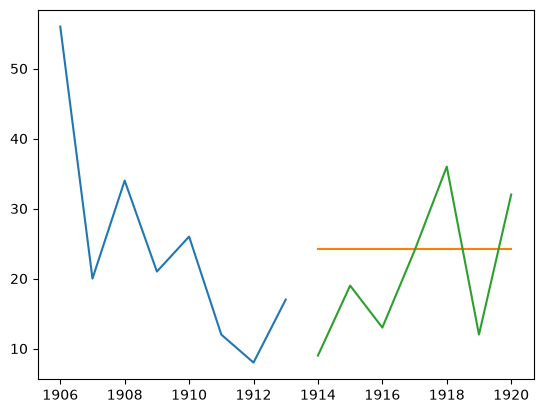

In [19]:
product_id = SALES_DF["id"].sample(1).item()

fig, ax = plt.subplots()

train_df = SALES_DF.filter(
    pl.col("id") == product_id,
    pl.col("d_index").is_between((MAX_TRAINING_TIMESTAMP - 7), MAX_TRAINING_TIMESTAMP)
).sort(by="d_index")

ax.plot(
    train_df["d_index"].to_list(),
    train_df["sales"].to_list(),
)
# ax.axhline(train_df["sales"].mean())

product_forecast_df = forecast_df.filter(pl.col('id') == product_id).sort(by="F_index")
ax.plot(
    product_forecast_df["F_index"].to_list(),
    product_forecast_df["sales"].to_list(),
)

product_valid_df = valid_df.filter(pl.col('id') == product_id).sort(by="d_index")
ax.plot(
    product_valid_df["d_index"].to_list(),
    product_valid_df["sales"].to_list(),
)

In [20]:
forecast_df

id,F_index,sales
str,i64,f64
"""HOUSEHOLD_1_106_TX_1""",1914,5.0
"""HOUSEHOLD_1_106_TX_1""",1915,5.0
"""HOUSEHOLD_1_106_TX_1""",1916,5.0
"""HOUSEHOLD_1_106_TX_1""",1917,5.0
"""HOUSEHOLD_1_106_TX_1""",1918,5.0
…,…,…
"""HOBBIES_1_354_TX_3""",1916,23.0
"""HOBBIES_1_354_TX_3""",1917,23.0
"""HOBBIES_1_354_TX_3""",1918,23.0


In [32]:
timesteps = range(FORECAST_HORIZON)
gamma = 0.95
product_ids = ["HOUSEHOLD_1_106_TX_1", "FOODS_3_376_TX_2"]

# Get forecasts by product id
product_demand_forecasts: dict[str, list[float]] = {}
for product_id in product_ids:
    product_forecast_df = forecast_df.filter(pl.col("id")==product_id).sort(by='F_index')
    product_demand_forecasts[product_id] = product_forecast_df["sales"].to_list()


# Get sales prices by product id
product_sale_prices: dict[str, list[float]] = {}
for product_id in product_ids:
    # TODO: Replace with actual sales prices
    product_sale_prices[product_id] = [9.5 for _ in range(FORECAST_HORIZON)]


# Get storage costs by product id
product_storage_prices: dict[str, list[float]] = {}
for product_id in product_ids:
    # TODO: Replace with actual storage prices
    product_storage_prices[product_id] = [3.5 for _ in range(FORECAST_HORIZON)]


# Get storage volume by product id
product_storage_volumes: dict[str, float] = {}
for product_id in product_ids:
    # TODO: Replace with actual storage prices
    product_storage_volumes[product_id] = 12.5


# Initial stock levels
initial_product_stock: dict[str, int] = {}
for product_id in product_ids:
    # TODO: Replace with actual inital stock levels
    initial_product_stock[product_id] = 5

# ==================
# DEFINE LP PROBLEM
# ==================
problem = pulp.LpProblem("mpc", sense=pulp.LpMinimize)


# ===============================
# DECISION / AUXILIARY VARIABLES
# ==============================
stock_addition_var = pulp.LpVariable.dicts("stock_addition", indices=(product_ids, timesteps), lowBound=0, cat=pulp.LpInteger)
stock_var = pulp.LpVariable.dicts("stock", indices=(product_ids, timesteps), lowBound=0, cat=pulp.LpInteger)

cost_aux_var = pulp.LpVariable.dicts("cost_aux", indices=(product_ids, timesteps), lowBound=0, cat=pulp.LpContinuous)
sales_aux_var = pulp.LpVariable.dicts("sales_aux", indices=(product_ids, timesteps), lowBound=0, cat=pulp.LpInteger)

# ==================
# Objective function

# Minimise the cost auxiliary variable.
# Cost auxiliary variable is a decomposition of costs from missing out on possible sales (under-stocking)
# and cost from having to store more than what was sold (over-stocking). This objective is formulated via
# constraints (see below).
# ==================
problem += (
    pulp.lpSum(
        gamma ** k * cost_aux_var[p][k]
        for k in timesteps
        for p in product_ids
    )
)

# ==================
# Constraints
# ==================

# 1. Constraint on initial stock levels.
for p in product_ids:
    problem += stock_var[p][0] == initial_product_stock[p]


# 2. Constraint on sales to be min(demand, stock + addition).
for k in timesteps:
    for p in product_ids:
        problem += sales_aux_var[p][k] <= product_demand_forecasts[p][k]
        problem += sales_aux_var[p][k] <= stock_var[p][k] + stock_addition_var[p][k]


for k in timesteps:
    for p in product_ids:

        # Constraint for missing out on possible sales (stocking less than demand)
        problem += (
            product_sale_prices[p][k] * (product_demand_forecasts[p][k] - sales_aux_var[p][k])
        ) <= cost_aux_var[p][k]

        # Constraint for storing more than expected demand
        problem += (
            product_storage_prices[p][k] * (stock_var[p][k] + stock_addition_var[p][k] - sales_aux_var[p][k])
        ) <= cost_aux_var[p][k]


# Storage capacity constraint
for k in timesteps:
    # TODO: Replace with actual storage capacity
    problem += pulp.lpSum(
        [
            (stock_var[p][k] + stock_addition_var[p][k]) *  product_storage_volumes[p]
            for p in product_ids
        ]
    ) <= 10_000


for p in product_ids:
    for k in timesteps[:-1]:
        problem += (
            stock_var[p][k+1]
            == (
                stock_var[p][k]
                + stock_addition_var[p][k]
                - sales_aux_var[p][k]
            )
        )

In [33]:
product_demand_forecasts

{'HOUSEHOLD_1_106_TX_1': [5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0],
 'FOODS_3_376_TX_2': [8.75, 8.75, 8.75, 8.75, 8.75, 8.75, 8.75]}

In [34]:
product_sale_prices

{'HOUSEHOLD_1_106_TX_1': [9.5, 9.5, 9.5, 9.5, 9.5, 9.5, 9.5],
 'FOODS_3_376_TX_2': [9.5, 9.5, 9.5, 9.5, 9.5, 9.5, 9.5]}

In [35]:
product_storage_prices

{'HOUSEHOLD_1_106_TX_1': [3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5],
 'FOODS_3_376_TX_2': [3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5]}

In [36]:
product_storage_volumes

{'HOUSEHOLD_1_106_TX_1': 12.5, 'FOODS_3_376_TX_2': 12.5}

In [37]:
initial_product_stock

{'HOUSEHOLD_1_106_TX_1': 5, 'FOODS_3_376_TX_2': 5}

In [38]:
problem.solve(pulp.PULP_CBC_CMD(msg=False))
pulp.LpStatus[problem.status]

'Optimal'